In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.datasets import fetch_california_housing
print("All libraries imported successfully")

All libraries imported successfully


In [2]:
data=fetch_california_housing(as_frame=True)
df=data.frame
print("Shape of dataset:",df.shape)
print(df.head())

Shape of dataset: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
print("Column Name:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Column Name:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Data Types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Basic Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   172

In [4]:
print("Checking for missing values in each column:")
print(df.isnull().sum())
print("\nTotal missing values:")
print(df.isnull().sum().sum())

Checking for missing values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values:
0


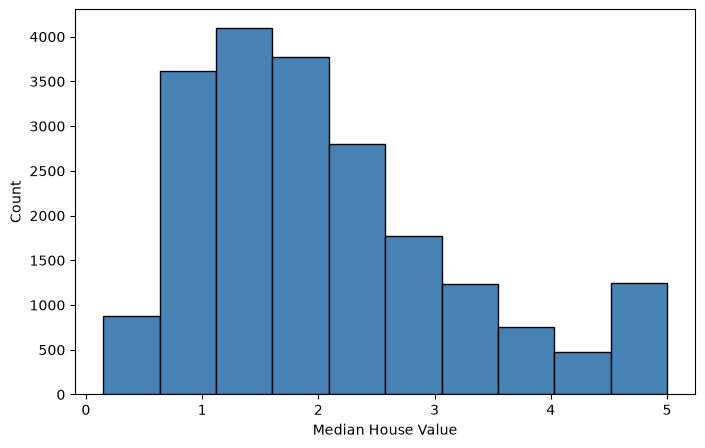

In [5]:
plt.figure(figsize=(8,5))
plt.hist(df['MedHouseVal'],color='steelblue',edgecolor='black')
plt.xlabel('Median House Value')
plt.ylabel('Count')
plt.show()

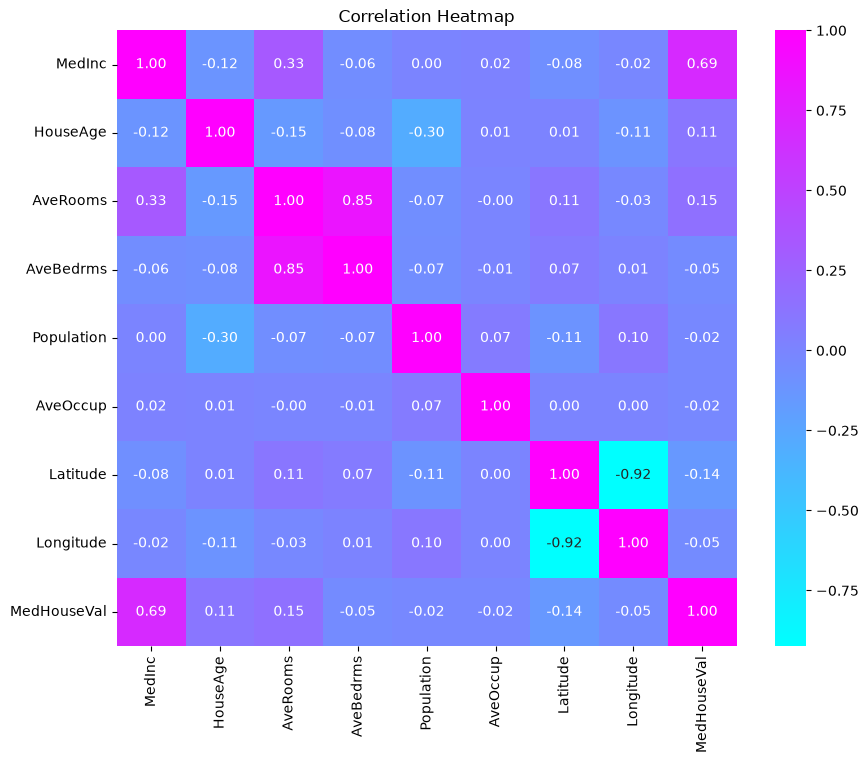

In [6]:
plt.figure(figsize=(10,8))
sb.heatmap(df.corr(),annot=True,cmap='cool',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Text(0, 0.5, 'Median House Value')

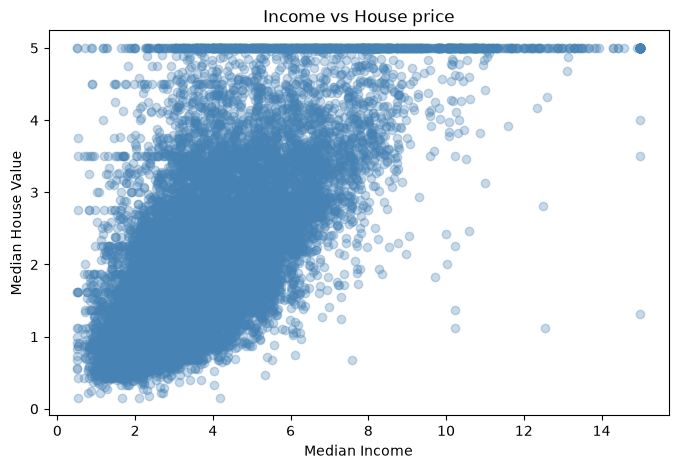

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(df['MedInc'],df['MedHouseVal'],alpha=0.3,color='steelblue')
plt.title('Income vs House price')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')

Text(0.5, 1.0, 'Box Plot')

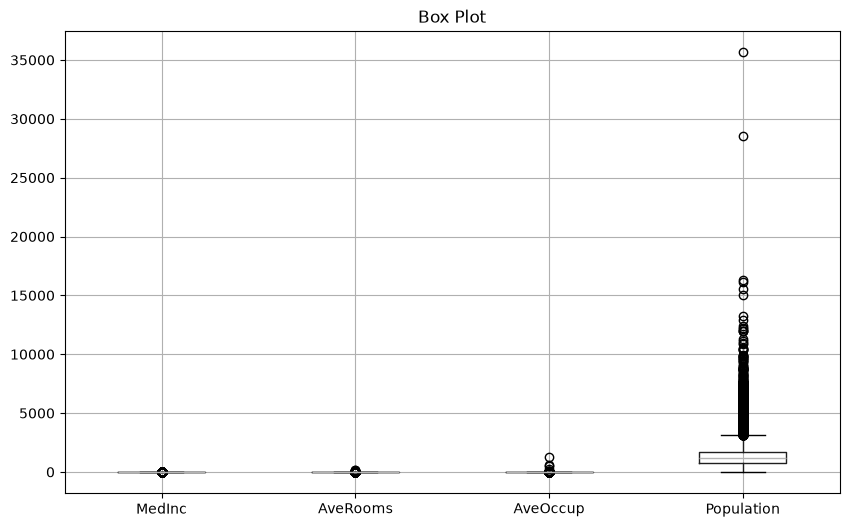

In [8]:
plt.figure(figsize=(10,6))
df.boxplot(column=['MedInc','AveRooms','AveOccup','Population'])
plt.title('Box Plot')

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x=df.drop('MedHouseVal',axis=1)
y=df['MedHouseVal']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
print("Training set size:",x_train.shape)
print("Testing set size:",x_test.shape)

Training set size: (16512, 8)
Testing set size: (4128, 8)


In [13]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Model trained successfully")
print("First 5 predictions:",y_pred[:5])
print("First 5 actual values:",y_test[:5].values)

Model trained successfully
First 5 predictions: [4.12159414 2.24292002 1.33617919 2.5607377  0.32148038]
First 5 actual values: [5.00001 2.502   4.5     1.918   0.685  ]


In [15]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("Model Evaluation:")
print(f"MAE  (Mean Absolute Error):  {mae:.2f}")
print(f"MSE  (Mean Squared Error):   {mse:.2f}")
print(f"RMSE (Root Mean Sq Error):   {rmse:.2f}")
print(f"R²   (R Squared Score):      {r2:.2f}")

Model Evaluation:
MAE  (Mean Absolute Error):  0.54
MSE  (Mean Squared Error):   0.54
RMSE (Root Mean Sq Error):   0.73
R²   (R Squared Score):      0.60


In [18]:
from sklearn.linear_model import Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor
models={
    'Linear Regression': LinearRegression(),
    'Ridge Regression':Ridge(),
    'Lasso Regression':Lasso(),
    'Random Forest':RandomForestRegressor(n_estimators=100,random_state=42)
}
print("Model Comparison:")
print("-"*50)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name}:")
    print(f"  R² = {r2:.2f}  RMSE = {rmse:.2f}")
    print("-" * 50)

Model Comparison:
--------------------------------------------------


NameError: name 'X_train' is not defined